### import libraries and dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ast import literal_eval
from collections import Counter
from wordcloud import WordCloud

In [2]:
df = pd.read_csv("datasets/games_cleaned.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89618 entries, 0 to 89617
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   appid                     89618 non-null  int64  
 1   name                      88168 non-null  object 
 2   required_age              89618 non-null  object 
 3   price                     89618 non-null  float64
 4   dlc_count                 89618 non-null  int64  
 5   mac                       89618 non-null  bool   
 6   linux                     89618 non-null  bool   
 7   metacritic_score          89618 non-null  int64  
 8   achievements              89618 non-null  int64  
 9   recommendations           89618 non-null  int64  
 10  positive                  89618 non-null  int64  
 11  negative                  89618 non-null  int64  
 12  estimated_owners          89618 non-null  int64  
 13  average_playtime_forever  89618 non-null  int64  
 14  median

### Adding new columns that are helpful for the analysis
*original_price* column is calculated into the dataset, for each row, it is obtained as price/(1-(discount/100)). After the operation, we noticed that there is a null value in the newly obtained attribute, further ispection shows that that row has current price 0 and a 100% discount, effectivly making the operation a division by 0 and results in a nan. It is manually corrected to original_price=0 <br><br>

In [ ]:
# Calculate original price based on discount
df["original_price"] = np.where(
    df["discount"] < 100,
    df["price"] / (1 - df["discount"] / 100),
    np.nan
)

In [3]:
# Check for rows where original_price is NaN due to 100% discount
err = df[['name', 'price', 'discount', 'original_price']][df['discount'] == 100]
print(err)

# Manually set original_price to 0 for rows with 100% discount
df.loc[df['name'].isin(err['name']), 'original_price'] = 0

KeyError: "['original_price'] not in index"

In [8]:
invalid = df[df['positive'] + df['negative'] != df['recommendations']]

if invalid.empty:
    print("All rows are valid.")
else:
    print("Invalid rows found:")
    print(invalid[['name', 'positive', 'negative', 'recommendations']])

Invalid rows found:
                                 name  positive  negative  recommendations
0                    counter_strike_2   7480813   1135108          4401572
1                  pubg_battlegrounds   1487960   1024436          1732007
2                              dota_2   1998462    451338            14337
3           grand_theft_auto_v_legacy   1719950    250012          1803063
4      tom_clancy_s_rainbow_six_siege   1152763    218446          1165929
...                               ...       ...       ...              ...
89613                     outrun_them         2         0                0
89614      lands_of_pharaoh_episode_1         2         0                0
89615                      player_one         2         1                0
89616                      dragonroad         2         0                0
89617              ragtag_adventurers         8         4                0

[73451 rows x 4 columns]


### What are the most cited categories
The *tag* column contains all the categories, i.e., tags that players believe best describe a game. <br>
The *tag* attribute take form of a dictionary of pair (key, count), where key represents a tag, and count represents the number of players believes that tag represents the game. <br> 
The following shows a **wordcloud** of such tags, arranged by the frequencies each tag (!= sum of counts) appeared in the dataset to show which categories of games appear more often according to players<br><br>
The result shows the visual impact of **[singleplayer, indie, action, casual, adventure]** are the most cited tags. This presents a public preference in games genres among the player community 

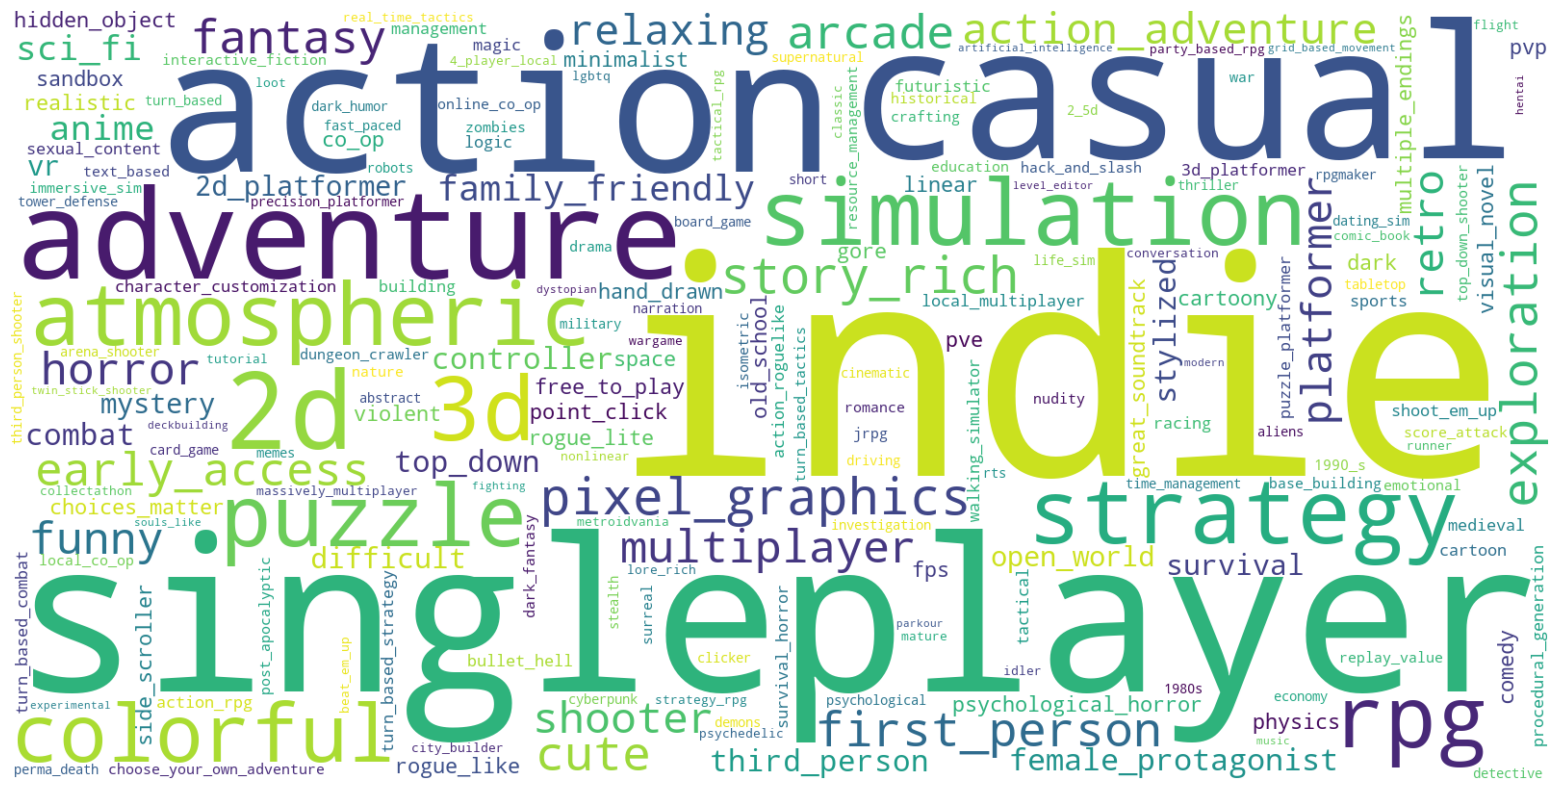

In [3]:
# Count only how often each tag key appears across rows
tag_counter = Counter()

for item in df["tags"]:
    tags_dict = literal_eval(item) if isinstance(item, str) else item
    if isinstance(tags_dict, dict):
        tag_counter.update(tags_dict.keys())  # count keys, not values

# Wordcloud
wc = WordCloud(width=1600, height=800, background_color="white")
wc.generate_from_frequencies(tag_counter)

plt.figure(figsize=(16, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.tight_layout()
plt.show()